# Python Assignment 14 :LGBM & XGBM

In [18]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [10]:
#load dataset

df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [12]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


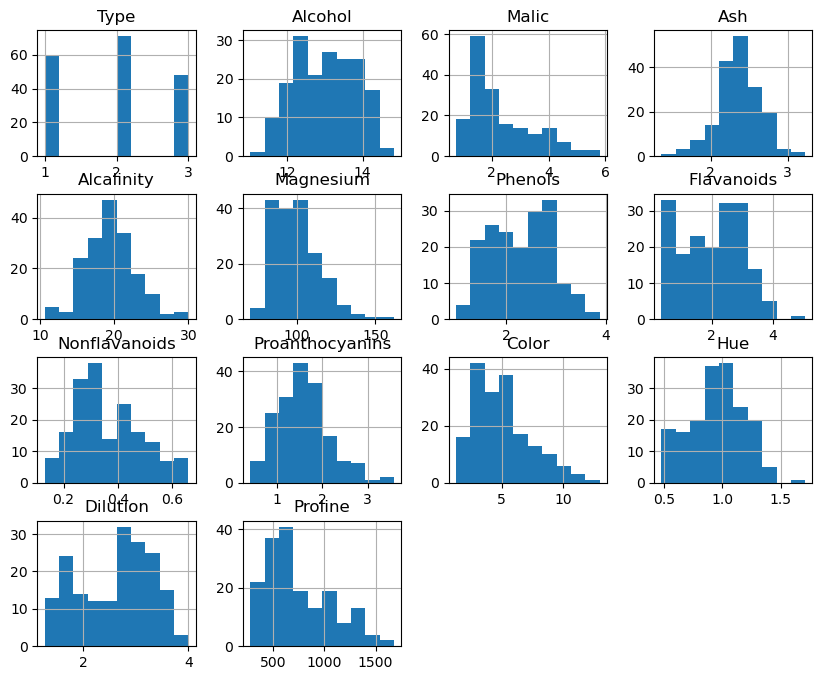

In [19]:
# Histograms
df.hist(figsize=(10,8))
plt.show()

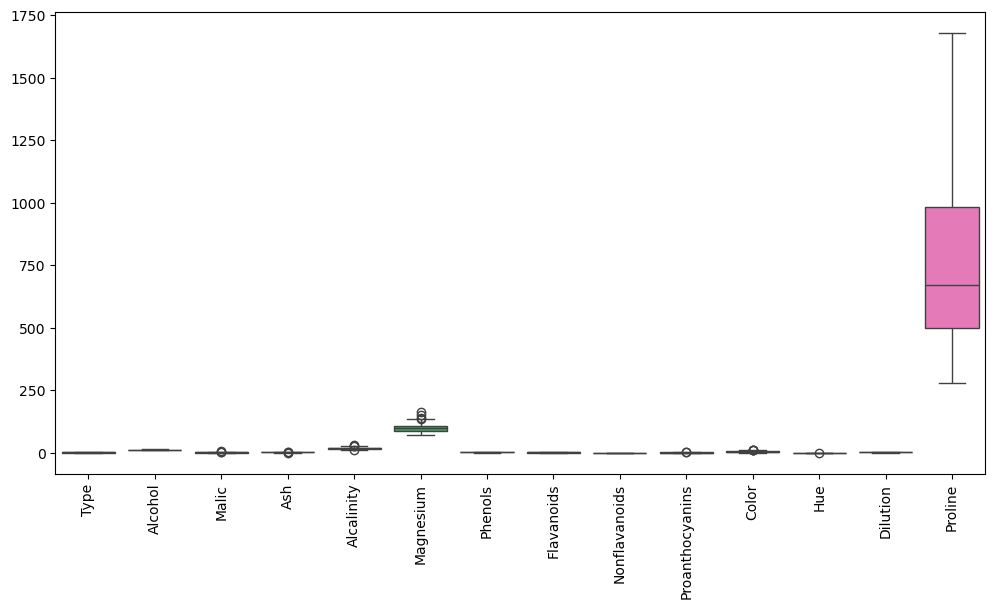

In [21]:
# box 

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

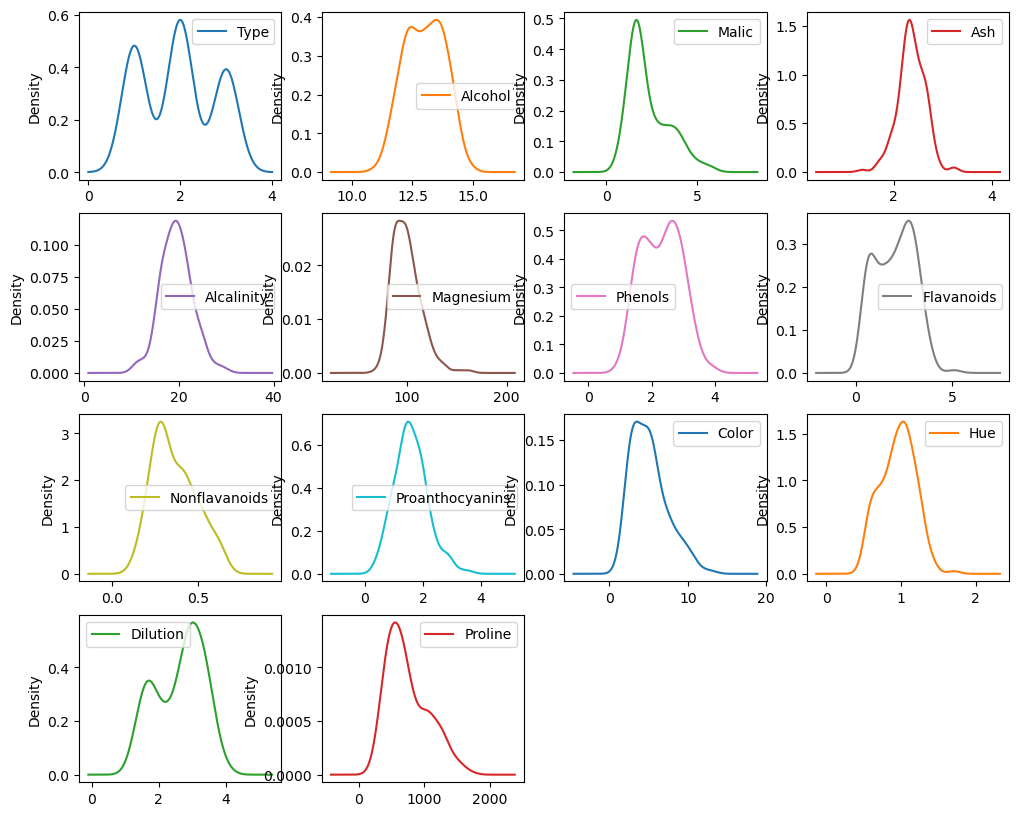

In [25]:
# density plot

df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.show()

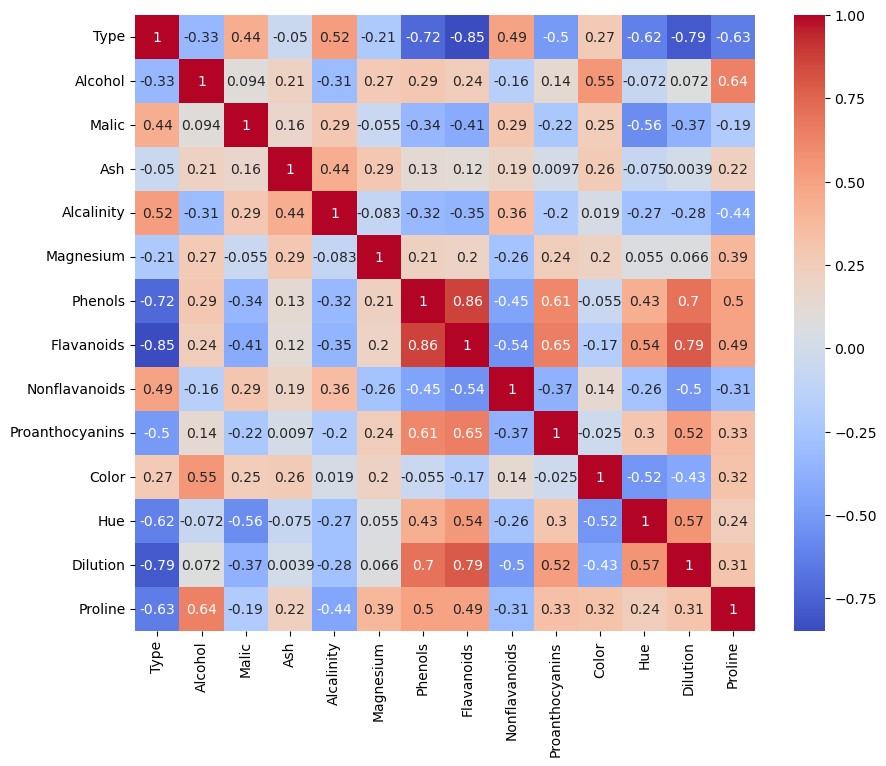

In [26]:
# correlation plot

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [38]:
# standerdize

from sklearn.preprocessing import StandardScaler

X = df.drop("Type", axis=1)  
y = df["Type"]               

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [39]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


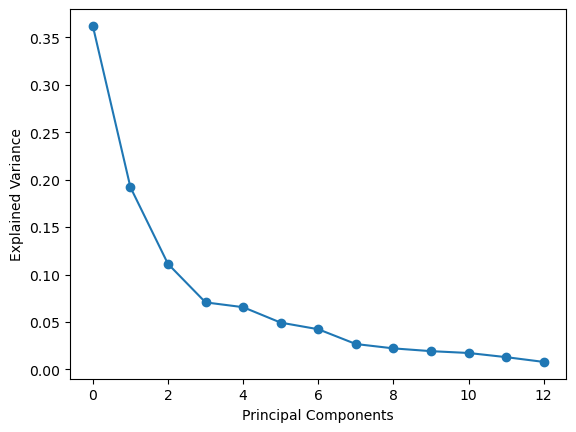

In [40]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()


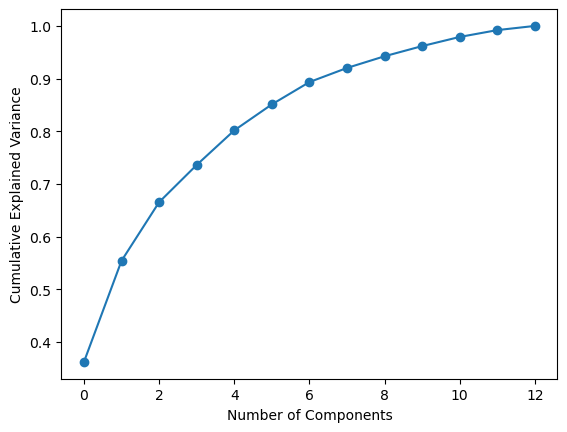

In [43]:
# Explained Variance

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()


In [45]:
pca_opt = PCA(n_components=5)
X_reduced = pca_opt.fit_transform(X_scaled)

print("Reduced Shape:", X_reduced.shape)


Reduced Shape: (178, 5)


In [46]:
X_reduced = pd.DataFrame(X_reduced)
print(X_reduced.head())
?

          0         1         2         3         4
0  3.316751  1.443463 -0.165739 -0.215631  0.693043
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655
2  2.516740  1.031151  0.982819  0.724902 -0.251033
3  3.757066  2.756372 -0.176192  0.567983 -0.311842
4  1.008908  0.869831  2.026688 -0.409766  0.298458



IPython -- An enhanced Interactive Python

IPython offers a fully compatible replacement for the standard Python
interpreter, with convenient shell features, special commands, command
history mechanism and output results caching.

At your system command line, type 'ipython -h' to see the command line
options available. This document only describes interactive features.

GETTING HELP
------------

Within IPython you have various way to access help:

  ?         -> Introduction and overview of IPython's features (this screen).
  object?   -> Details about 'object'.
  object??  -> More detailed, verbose information about 'object'.
  %quickref -> Quick reference of all IPython specific syntax and magics.
  help      -> Access Python's own help system.

If you are in terminal IPython you can quit this screen by pressing `q`.


MAIN FEATURES
-------------

* Access to the standard Python help with object docstrings and the Python
  manuals. Simply type 'help' (no quotes) to invoke it.

* Ma

In [47]:
from sklearn.cluster import KMeans

# Choose number of clusters (start with 3 for wine dataset)
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df["Cluster"] = clusters


C:\Users\Thasin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


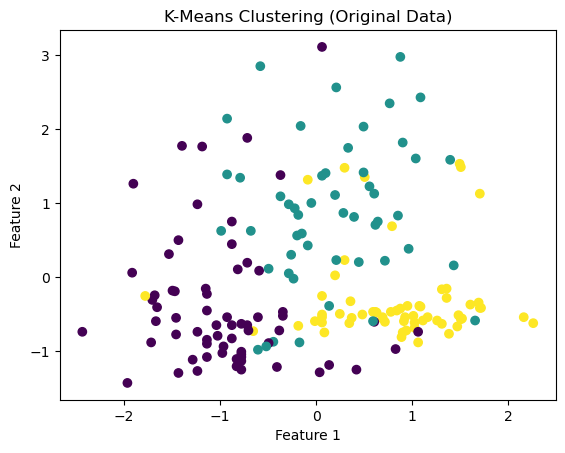

In [60]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering (Original Data)")
plt.show()


In [61]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.2848589191898987


In [62]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_scaled, clusters)
print("Davies-Bouldin Index:", db_score)


Davies-Bouldin Index: 1.389187977718165


In [63]:
# with PCA

from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=3, random_state=42)

clusters_pca = kmeans_pca.fit_predict(X_reduced)


C:\Users\Thasin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


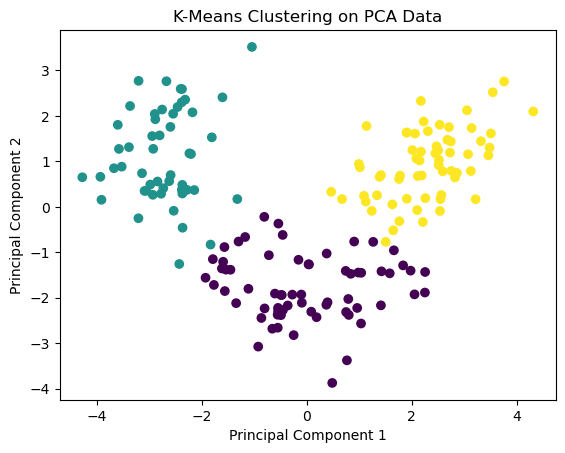

In [64]:
plt.scatter(X_reduced.iloc[:, 0], X_reduced.iloc[:, 1], c=clusters_pca)
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [65]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_pca = silhouette_score(X_reduced, clusters_pca)
db_pca = davies_bouldin_score(X_reduced, clusters_pca)

print("PCA Silhouette Score:", sil_pca)
print("PCA Davies-Bouldin Index:", db_pca)


PCA Silhouette Score: 0.36907631946992286
PCA Davies-Bouldin Index: 1.0932987882612908


In [66]:
print("Original Silhouette:", sil_score)
print("PCA Silhouette:", sil_pca)

print("Original DB Index:", db_score)
print("PCA DB Index:", db_pca)


Original Silhouette: 0.2848589191898987
PCA Silhouette: 0.36907631946992286
Original DB Index: 1.389187977718165
PCA DB Index: 1.0932987882612908
